In [195]:
import pandas as pd # data manipulation
import numpy as np # linear algebra

from sklearn.model_selection import train_test_split # spliting dataframe into training and testing
from sklearn.preprocessing import StandardScaler # for data transformation
# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [196]:
df = pd.read_csv('Social_Network_Ads.csv').iloc[:,2:]
df.sample(6)

,Age,EstimatedSalary,Purchased
368,38,71000,0
371,60,83000,1
328,36,118000,1
277,49,88000,1
289,37,78000,1
134,28,55000,0


In [197]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [199]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [200]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [201]:
print('Mean of Scaled Data:', scaler.mean_)

Mean of Scaled Data: [3.7871875e+01 7.0281250e+04]


In [202]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [203]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


### Effects of Scaling

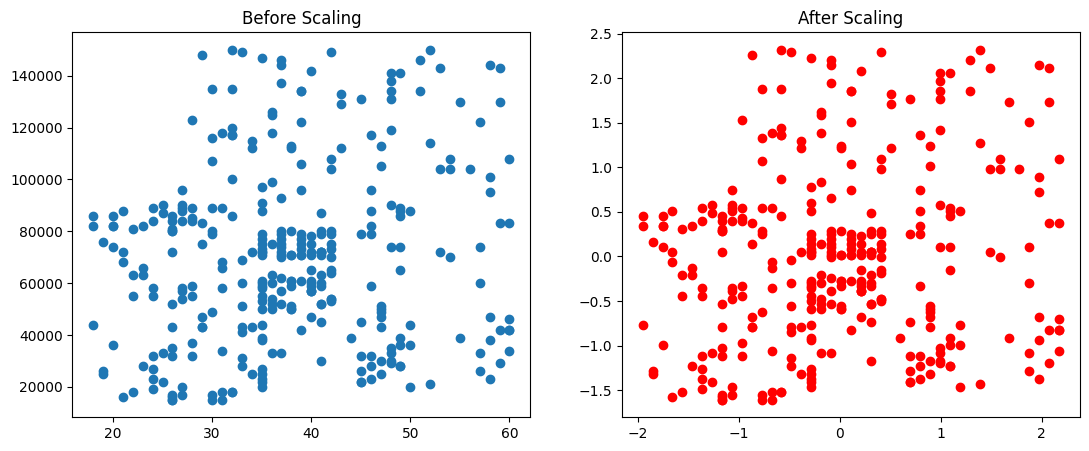

In [204]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Scaling')

plt.show()

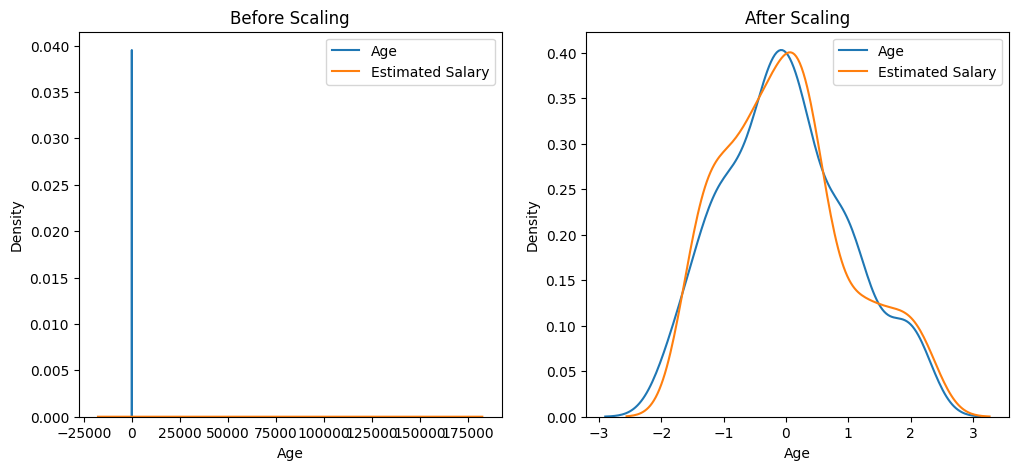

In [205]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Estimated Salary')
ax1.legend(title='')

# After Scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='Estimated Salary')
ax2.legend(title='')

plt.show()

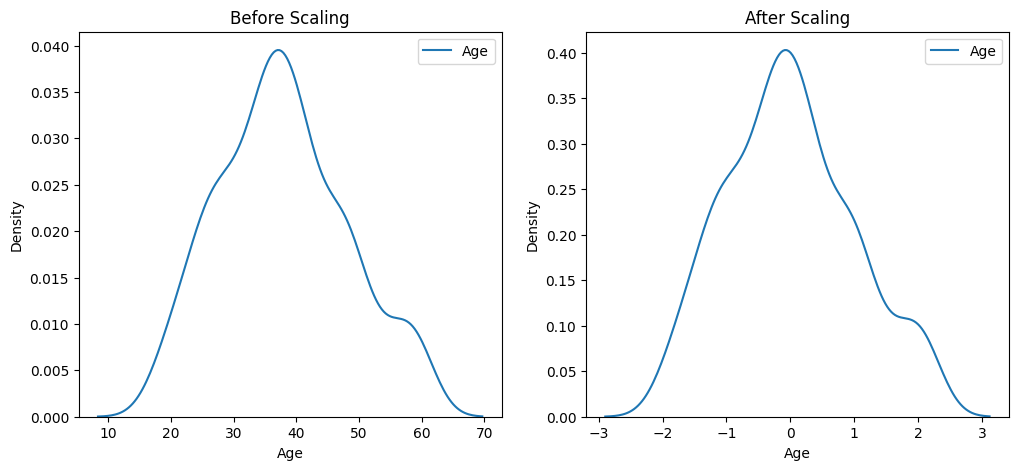

In [206]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age')
ax1.legend(title='')

# After Scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age')
ax2.legend(title='')

plt.show()

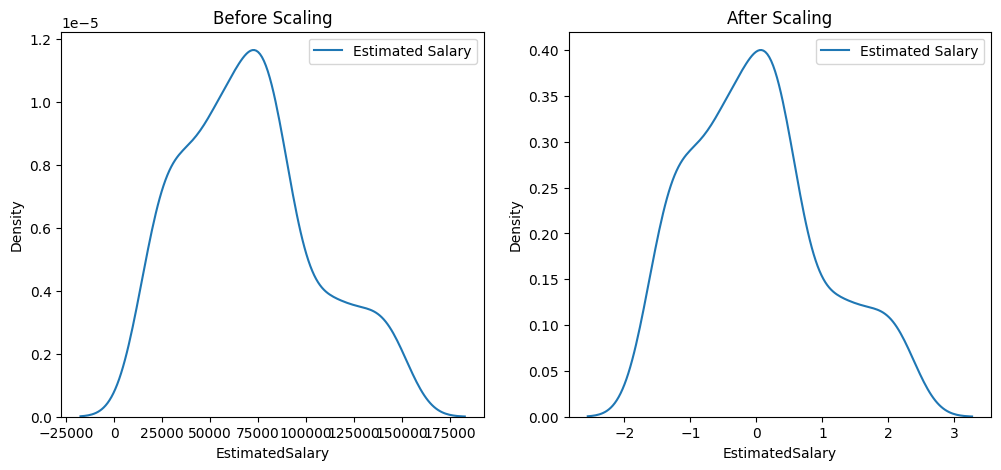

In [207]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Estimated Salary')
ax1.legend(title='')

# After Scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='Estimated Salary')
ax2.legend(title='')

plt.show()

In [208]:
log_reg = LogisticRegression()
log_reg_scaled = LogisticRegression()

log_reg.fit(X_train, y_train)
ypred_log_reg = log_reg.predict(X_test)
print('Accuracy Before Standardization: {:.2f}%'.format(accuracy_score(y_test, ypred_log_reg)))

log_reg_scaled.fit(X_train_scaled, y_train)
ypred_scaled_log_reg = log_reg.predict(X_test_scaled)
print('Accuracy After Standardization: {:.2f}%'.format(accuracy_score(y_test, ypred_scaled_log_reg)))

Accuracy Before Standardization: 0.89%
Accuracy After Standardization: 0.65%


weird here the accuracy reduced after Standardization !!

In [209]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train, y_train)
ypred_dt = dt.predict(X_test)
print('Accuracy Before Standardization: {:.2f}%'.format(accuracy_score(y_test, ypred_dt)))

dt_scaled.fit(X_train_scaled, y_train)
ypred_dt_scaled = dt.predict(X_test_scaled)
print('Accuracy Before Standardization: {:.2f}%'.format(accuracy_score(y_test, ypred_dt_scaled)))

Accuracy Before Standardization: 0.84%
Accuracy Before Standardization: 0.65%


### Effects Of Outlier

In [210]:
df = pd.concat([df,
               pd.DataFrame(
                   {'Age':[50, 100, 95], 'EstimatedSalary': [10000000, 25, 30000000], 'Purchased': [1, 0, 1]
                   })
               ], ignore_index=True)

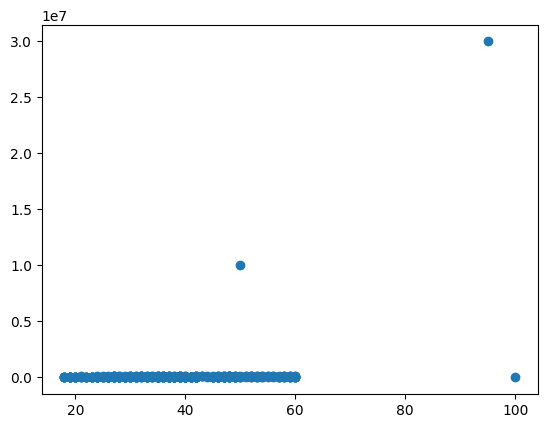

In [211]:
plt.scatter(df['Age'], df['EstimatedSalary'])
plt.show()

In [212]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

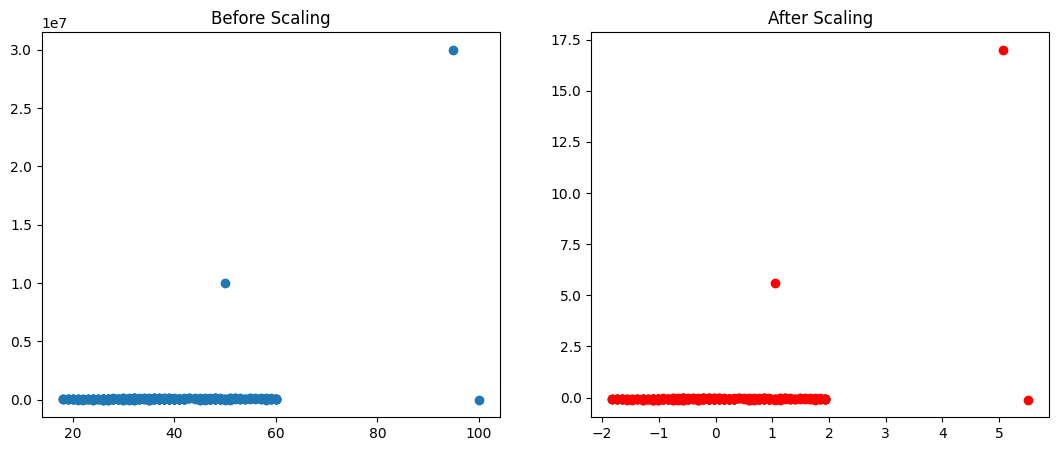

In [213]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(13, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Scaling')

plt.show()

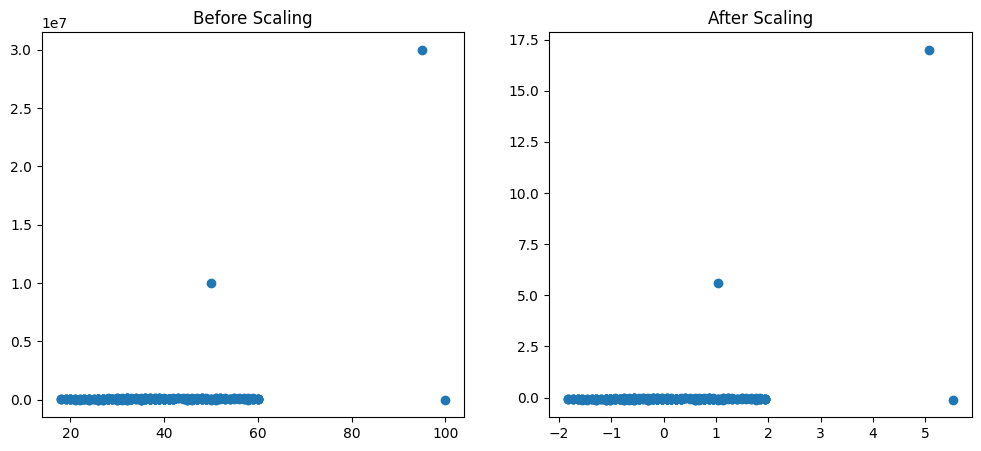

In [214]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Scaling')
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])


# After Scaling
ax2.set_title('After Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'])

plt.show()